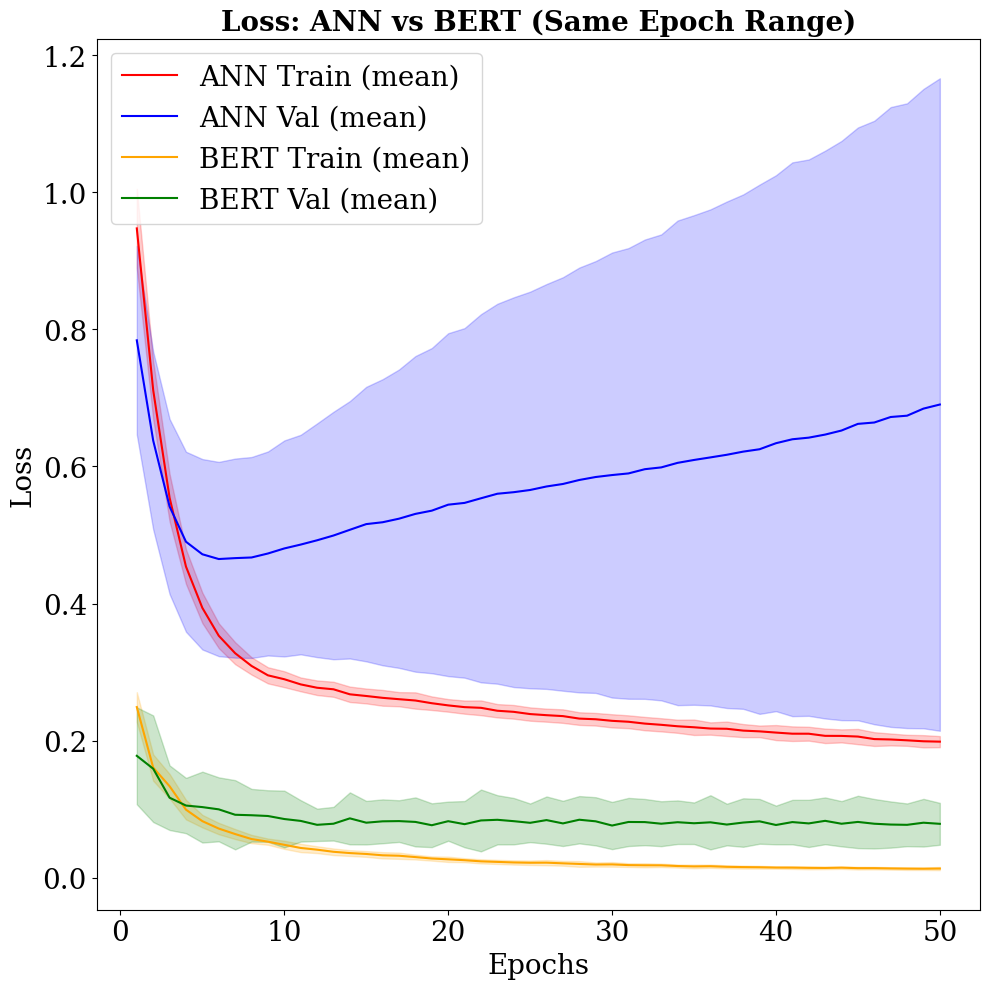

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load DNN losses (1000 epochs)
dnn_data = np.load("all_seed_losses_DNN.npz", allow_pickle=True)
dnn_train = np.stack([dnn_data["train_losses"].item()[s] for s in sorted(dnn_data["train_losses"].item())])
dnn_val = np.stack([dnn_data["val_losses"].item()[s] for s in sorted(dnn_data["val_losses"].item())])
dnn_train_mean = dnn_train.mean(axis=0)
dnn_val_mean = dnn_val.mean(axis=0)
dnn_train_std = dnn_train.std(axis=0)
dnn_val_std = dnn_val.std(axis=0)

# Load BERT losses (50 epochs)
bert_data = np.load("all_seed_losses.npz", allow_pickle=True)
bert_train = np.stack([bert_data["train_losses"].item()[s] for s in sorted(bert_data["train_losses"].item())])
bert_val = np.stack([bert_data["val_losses"].item()[s] for s in sorted(bert_data["val_losses"].item())])
bert_train_mean = bert_train.mean(axis=0)
bert_train_std = bert_train.std(axis=0)
bert_val_mean = bert_val.mean(axis=0)
bert_val_std = bert_val.std(axis=0)

# Truncate DNN to match BERT epochs
min_epochs = min(len(dnn_val_mean), len(bert_val_mean))
dnn_val_mean = dnn_val_mean[:min_epochs]
dnn_train_mean = dnn_train_mean[:min_epochs]
dnn_val_std = dnn_val_std[:min_epochs]
dnn_train_std = dnn_train_std[:min_epochs]
bert_val_mean = bert_val_mean[:min_epochs]
bert_val_std = bert_val_std[:min_epochs]
bert_train_mean = bert_train_mean[:min_epochs]
bert_train_std = bert_train_std[:min_epochs]

# Epochs
epochs = range(1, min_epochs + 1)

# Plot
plt.figure(figsize=(10, 10))
plt.rcParams['font.family'] = 'serif'  # or 'sans-serif', 'monospace', 'cursive', 'fantasy'
plt.rcParams['font.serif'] = ['DejaVu Serif'] # Specify a particular font within the family
plt.rc('axes', titlesize=20) # Sets the font size for axes titles
plt.rc('axes', labelsize=20) # Sets the font size for axes labels
plt.rc('xtick', labelsize=20) # Sets the font size for x-axis tick labels
plt.rc('ytick', labelsize=20) # Sets the font size for y-axis tick labels
plt.rc('legend', fontsize=20) # Sets the font size for the legend
plt.plot(epochs, dnn_train_mean, label="ANN Train (mean)", color="red")
plt.fill_between(epochs, dnn_train_mean - dnn_train_std, dnn_train_mean + dnn_train_std, alpha=0.2, color="red")
plt.plot(epochs, dnn_val_mean, label="ANN Val (mean)", color="blue")
plt.fill_between(epochs, dnn_val_mean - dnn_val_std, dnn_val_mean + dnn_val_std, alpha=0.2, color="blue")

plt.plot(epochs, bert_train_mean, label="BERT Train (mean)", color="orange")
plt.fill_between(epochs, bert_train_mean - bert_train_std, bert_train_mean + bert_train_std, alpha=0.2, color="orange")
plt.plot(epochs, bert_val_mean, label="BERT Val (mean)", color="green")
plt.fill_between(epochs, bert_val_mean - bert_val_std, bert_val_mean + bert_val_std, alpha=0.2, color="green")





plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss: ANN vs BERT (Same Epoch Range)",fontweight='bold')
plt.legend()
# plt.grid(True)
plt.tight_layout()
plt.show()

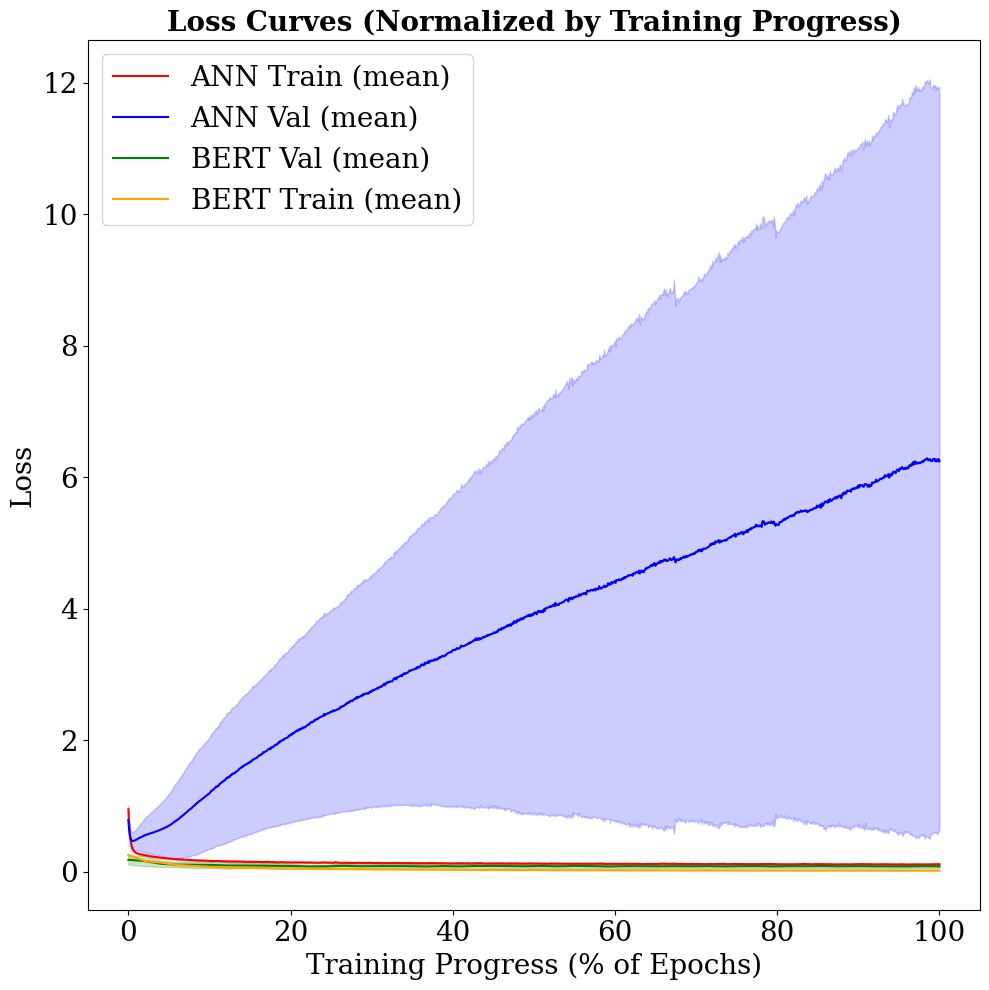

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load DNN losses (1000 epochs)
dnn_data = np.load("all_seed_losses_DNN.npz", allow_pickle=True)
dnn_train = np.stack([dnn_data["train_losses"].item()[s] for s in sorted(dnn_data["train_losses"].item())])
dnn_val = np.stack([dnn_data["val_losses"].item()[s] for s in sorted(dnn_data["val_losses"].item())])
dnn_train_mean = dnn_train.mean(axis=0)
dnn_val_mean = dnn_val.mean(axis=0)
dnn_train_std = dnn_train.std(axis=0)
dnn_val_std = dnn_val.std(axis=0)

# Load BERT losses (50 epochs)
bert_data = np.load("all_seed_losses.npz", allow_pickle=True)
bert_train = np.stack([bert_data["train_losses"].item()[s] for s in sorted(bert_data["train_losses"].item())])
bert_val = np.stack([bert_data["val_losses"].item()[s] for s in sorted(bert_data["val_losses"].item())])
bert_train_mean = bert_train.mean(axis=0)
bert_train_std = bert_train.std(axis=0)
bert_val_mean = bert_val.mean(axis=0)
bert_val_std = bert_val.std(axis=0)

# Create % epoch scale (normalized from 0 to 1)
dnn_epochs = np.linspace(0, 100, len(dnn_train_mean))
bert_epochs = np.linspace(0, 100, len(bert_train_mean))

# Plot
plt.figure(figsize=(10, 10))
plt.rcParams['font.family'] = 'serif'  # or 'sans-serif', 'monospace', 'cursive', 'fantasy'
plt.rcParams['font.serif'] = ['DejaVu Serif'] # Specify a particular font within the family
plt.rc('axes', titlesize=20) # Sets the font size for axes titles
plt.rc('axes', labelsize=20) # Sets the font size for axes labels
plt.rc('xtick', labelsize=20) # Sets the font size for x-axis tick labels
plt.rc('ytick', labelsize=20) # Sets the font size for y-axis tick labels
plt.rc('legend', fontsize=20) # Sets the font size for the legend

# DNN Loss
plt.plot(dnn_epochs, dnn_train_mean, label="ANN Train (mean)", color="red")
plt.fill_between(dnn_epochs, dnn_train_mean - dnn_train_std, dnn_train_mean + dnn_train_std, alpha=0.2, color="red")
plt.plot(dnn_epochs, dnn_val_mean, label="ANN Val (mean)", color="blue")
plt.fill_between(dnn_epochs, dnn_val_mean - dnn_val_std, dnn_val_mean + dnn_val_std, alpha=0.2, color="blue")



# BERT Loss
plt.plot(bert_epochs, bert_val_mean, label="BERT Val (mean)", color="green")
plt.fill_between(bert_epochs, bert_val_mean - bert_val_std, bert_val_mean + bert_val_std, alpha=0.2, color="green")

plt.plot(bert_epochs, bert_train_mean, label="BERT Train (mean)", color="orange")
plt.fill_between(bert_epochs, bert_train_mean - bert_train_std, bert_train_mean + bert_train_std, alpha=0.2, color="orange")

plt.xlabel("Training Progress (% of Epochs)")
plt.ylabel("Loss")
plt.title("Loss Curves (Normalized by Training Progress)",fontweight='bold')
plt.legend()
# plt.grid(True)
plt.tight_layout()
plt.show()

Best seed based on val_mse: 52


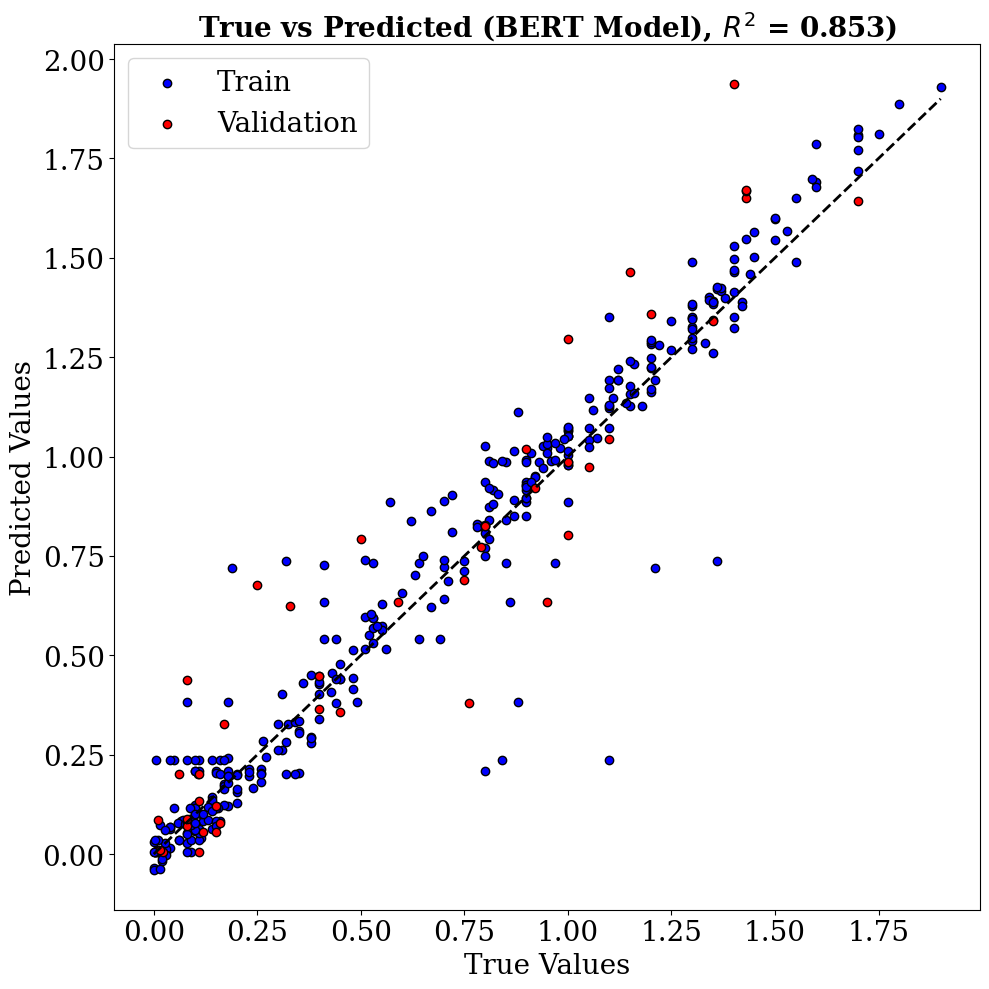

In [ ]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Step 1: Load files ===
metrics_df = pd.read_csv("bert_seed_metrics.csv")

with open("bert_seed_true_pred.pkl", "rb") as f:
    all_preds_data = pickle.load(f)

# === Step 2: Find the best-performing seed by lowest val_mse ===
best_row = metrics_df.loc[metrics_df["val_mse"].idxmin()]
best_seed = int(best_row["seed"])
print(f"Best seed based on val_mse: {best_seed}")

# === Step 3: Extract data ===
data = all_preds_data[best_seed]
train_trues = np.array(data["train_trues"])
train_preds = np.array(data["train_preds"])
val_trues = np.array(data["val_trues"])
val_preds = np.array(data["val_preds"])

# === Step 4: Compute R² score for val set ===
r2_val = r2_score(val_trues, val_preds)

# === Step 5: Plot ===
plt.figure(figsize=(10, 10))
plt.rcParams['font.family'] = 'serif'  # or 'sans-serif', 'monospace', 'cursive', 'fantasy'
plt.rcParams['font.serif'] = ['DejaVu Serif'] # Specify a particular font within the family
plt.rc('axes', titlesize=20) # Sets the font size for axes titles
plt.rc('axes', labelsize=20) # Sets the font size for axes labels
plt.rc('xtick', labelsize=20) # Sets the font size for x-axis tick labels
plt.rc('ytick', labelsize=20) # Sets the font size for y-axis tick labels
plt.rc('legend', fontsize=20) # Sets the font size for the legend
plt.scatter(train_trues, train_preds, alpha=1., label="Train", color= 'blue', edgecolor='k')
plt.scatter(val_trues, val_preds, alpha=1., label="Validation", color= 'red', edgecolor='k')
min_val = min(train_trues.min(), val_trues.min())
max_val = max(train_trues.max(), val_trues.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"True vs Predicted (BERT Model), $R^2$ = {r2_val:.3f})",fontweight='bold')
plt.legend()
plt.grid(False)
plt.tight_layout()
# plt.savefig("true_vs_predicted_best_seed_from_csv.png")
plt.show()

Best seed based on val_mse: 5966


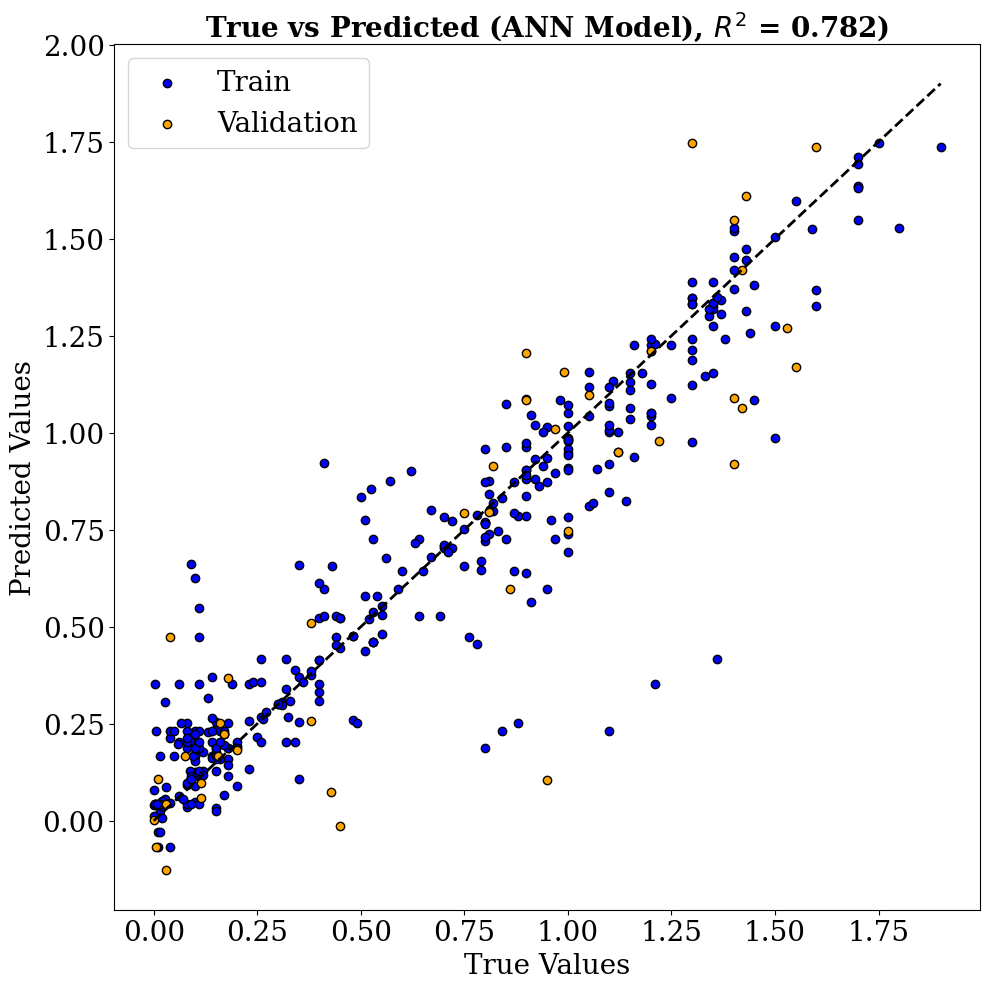

In [ ]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Step 1: Load files ===
metrics_df = pd.read_csv("dnn_seed_metrics.csv")

with open("all_seed_true_pred_dnn.pkl", "rb") as f:
    all_preds_data = pickle.load(f)

# === Step 2: Find the best-performing seed by lowest val_mse ===
best_row = metrics_df.loc[metrics_df["val_mse"].idxmin()]
best_seed = int(best_row["seed"])
print(f"Best seed based on val_mse: {best_seed}")

# === Step 3: Extract data ===
data = all_preds_data[best_seed]
train_trues = np.array(data["train_trues"])
train_preds = np.array(data["train_preds"])
val_trues = np.array(data["val_trues"])
val_preds = np.array(data["val_preds"])

# === Step 4: Compute R² score for val set ===
r2_val = r2_score(val_trues, val_preds)

# === Step 5: Plot ===
plt.figure(figsize=(10, 10))
plt.rcParams['font.family'] = 'serif'  # or 'sans-serif', 'monospace', 'cursive', 'fantasy'
plt.rcParams['font.serif'] = ['DejaVu Serif'] # Specify a particular font within the family
plt.rc('axes', titlesize=20) # Sets the font size for axes titles
plt.rc('axes', labelsize=20) # Sets the font size for axes labels
plt.rc('xtick', labelsize=20) # Sets the font size for x-axis tick labels
plt.rc('ytick', labelsize=20) # Sets the font size for y-axis tick labels
plt.rc('legend', fontsize=20) # Sets the font size for the legend
plt.scatter(train_trues, train_preds, alpha=1., label="Train", color= 'blue', edgecolor='k')
plt.scatter(val_trues, val_preds, alpha=1., label="Validation", color= 'orange', edgecolor='k')
min_val = min(train_trues.min(), val_trues.min())
max_val = max(train_trues.max(), val_trues.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"True vs Predicted (ANN Model), $R^2$ = {r2_val:.3f})",fontweight='bold')
plt.legend()
plt.grid(False)
plt.tight_layout()
# plt.savefig("true_vs_predicted_best_seed_from_csv.png")
plt.show()

In [ ]:
import pandas as pd

# Load metrics
bert_df = pd.read_csv("bert_seed_metrics.csv")
dnn_df = pd.read_csv("dnn_seed_metrics.csv")

def summarize(df, model_name):
    best_row = df.loc[df["val_mse"].idxmin()]
    summary = {
        "Model": model_name,
        "Best MAE": best_row["val_mae"],
        "Best MSE": best_row["val_mse"],
        "Best R2": best_row["val_r2"],
        "Mean MAE": df["val_mae"].mean(),
        "Std MAE": df["val_mae"].std(),
        "Mean MSE": df["val_mse"].mean(),
        "Std MSE": df["val_mse"].std(),
        "Mean R2": df["val_r2"].mean(),
        "Std R2": df["val_r2"].std(),
    }
    return summary

bert_summary = summarize(bert_df, "BERT")
dnn_summary = summarize(dnn_df, "DNN")

summary_df = pd.DataFrame([bert_summary, dnn_summary])
summary_df = summary_df.round(4)  # optional: round for display
summary_df.to_csv("model_comparison_summary.csv", index=False)
summary_df

,Model,Best MAE,Best MSE,Best R2,Mean MAE,Std MAE,Mean MSE,Std MSE,Mean R2,Std R2
0,BERT,0.1388,0.0373,0.8527,0.1996,0.0295,0.0860,0.0264,0.6433,0.1247
1,DNN,0.1846,0.0644,0.7824,0.4793,0.2010,1.8983,1.7835,-6.8143,7.1057
